In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv('cheating_detection_dataset_7.csv')
df
df.info()
df.archetype.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5189 entries, 0 to 5188
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   participant_id               5189 non-null   int64  
 1   competition_id               5189 non-null   int64  
 2   total_submissions            5189 non-null   int64  
 3   active_days_pct              5189 non-null   float64
 4   submissions_per_day          5189 non-null   float64
 5   submission_avg_initial_days  5189 non-null   float64
 6   avg_submissions_mid          5189 non-null   float64
 7   submissions_end              5189 non-null   int64  
 8   median_score                 5189 non-null   float64
 9   top_score                    5189 non-null   float64
 10  lowest_score                 5189 non-null   float64
 11  gap_median_top               5189 non-null   float64
 12  gap_lowest_top               5189 non-null   float64
 13  peak_submissions_p

array(['hardworker', 'consistent_late_breakthrough',
       'late_joiner_dangerous', 'consistent_ai_leap',
       'low_interest_quitter', 'benchmark_tweaker', 'daily_sprinter',
       'ai_dump_sincere_start', 'pure_ai_quick_dump'], dtype=object)

In [9]:
df.describe()

,participant_id,competition_id,total_submissions,active_days_pct,submissions_per_day,submission_avg_initial_days,avg_submissions_mid,submissions_end,median_score,top_score,...,time_to_best_score_hours,submissions_pre_jump,submissions_post_jump,leap_size,post_jump_score_repetition,quiz_participation_pct,final_rank,rank_to_submissions,rank_to_quiz_participation,description_rate
count,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,...,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000,5189.000000
mean,2595.000000,81.207940,17.038158,59.531702,2.934630,1.253806,1.862530,2.102139,0.759614,0.548847,...,107.777613,6.557140,10.481018,0.767693,0.293083,57.795336,17.875506,2.453407,2.991224,0.730516
std,1498.079604,45.418882,10.522569,27.254766,1.427655,1.088662,1.503640,2.546025,0.289485,0.211192,...,74.310497,6.694316,8.670279,0.659607,0.343402,17.885411,11.138415,4.205802,2.594114,0.154997
min,1.000000,1.000000,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.394673,0.300000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.013699,0.090909,0.000000
25%,1298.000000,42.000000,8.000000,40.000000,2.000000,0.333333,0.666667,0.000000,0.586992,0.433466,...,35.296754,2.000000,4.000000,0.222899,0.000000,50.000000,9.000000,0.411765,1.250000,0.650000
50%,2595.000000,81.000000,16.000000,60.000000,2.666667,1.000000,1.666667,1.000000,0.664069,0.499922,...,110.323553,4.000000,8.000000,0.423486,0.097405,60.000000,17.000000,1.000000,2.400000,0.750000
75%,3892.000000,120.000000,23.000000,80.000000,3.500000,2.000000,2.666667,3.000000,0.793056,0.574721,...,173.942939,9.000000,16.000000,1.467803,0.600896,70.000000,26.000000,2.400000,4.000000,0.826000
max,5189.000000,160.000000,75.000000,100.000000,10.000000,6.000000,9.666667,10.000000,2.430249,2.430249,...,238.946767,68.000000,63.000000,2.241050,1.000000,100.000000,46.000000,46.000000,39.000000,1.000000


In [10]:
df = df.drop(columns = ['participant_id','competition_id'])
df


,total_submissions,active_days_pct,submissions_per_day,submission_avg_initial_days,avg_submissions_mid,submissions_end,median_score,top_score,lowest_score,gap_median_top,...,submissions_pre_jump,submissions_post_jump,leap_size,post_jump_score_repetition,quiz_participation_pct,final_rank,rank_to_submissions,rank_to_quiz_participation,description_rate,archetype
0,4,40.0,1.000000,0.333333,0.333333,0,0.910711,0.869639,1.065738,0.041072,...,1,3,0.119495,0.418684,60.0,17,4.250000,2.428571,0.750,hardworker
1,4,30.0,1.333333,0.000000,1.000000,1,1.200012,1.112830,1.287193,0.087181,...,4,0,0.000000,0.000000,80.0,18,4.500000,2.000000,0.500,consistent_late_breakthrough
2,18,30.0,6.000000,0.000000,0.666667,0,0.561328,0.512454,0.615423,0.048873,...,2,16,0.063731,0.000000,60.0,10,0.555556,1.428571,0.667,late_joiner_dangerous
3,21,70.0,3.000000,1.333333,0.666667,3,0.592643,0.358047,2.260090,0.234596,...,8,13,1.667447,0.722339,30.0,2,0.095238,0.500000,0.810,consistent_late_breakthrough
4,27,60.0,4.500000,0.666667,1.666667,3,0.622750,0.440728,1.029055,0.182022,...,3,24,0.486757,0.006387,40.0,7,0.259259,1.400000,0.815,consistent_ai_leap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5184,17,30.0,5.666667,0.000000,5.000000,2,0.611877,0.435450,2.390095,0.176426,...,1,16,1.685680,0.000000,60.0,2,0.117647,0.285714,0.765,late_joiner_dangerous
5185,16,20.0,8.000000,0.000000,2.000000,0,0.591978,0.510059,2.118979,0.081918,...,1,15,1.380856,0.098688,50.0,7,0.437500,1.166667,0.625,late_joiner_dangerous
5186,2,20.0,1.000000,0.000000,0.000000,0,1.158344,1.122809,1.193880,0.035536,...,2,0,0.000000,0.000000,70.0,21,10.500000,2.625000,1.000,hardworker
5187,27,50.0,5.400000,5.666667,0.666667,0,1.575702,0.580214,2.410464,0.995487,...,20,7,1.816358,0.866817,50.0,16,0.592593,2.666667,0.815,ai_dump_sincere_start


In [11]:
print(df.duplicated().sum())
df = df[df.duplicated() == False]
print(df.duplicated().sum())
df.head()
df.shape

0
0


(5189, 30)

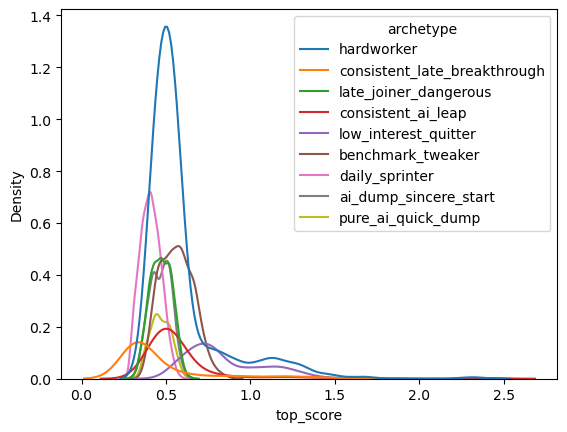

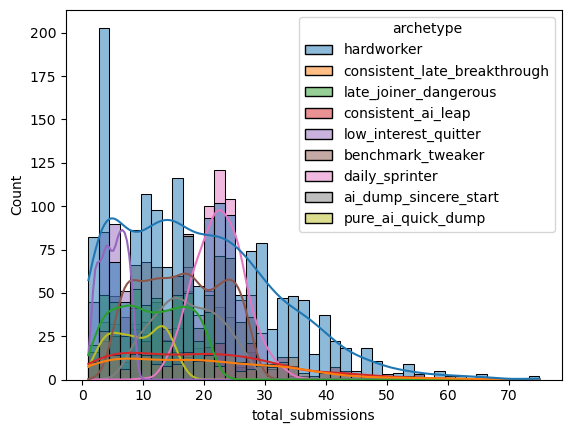

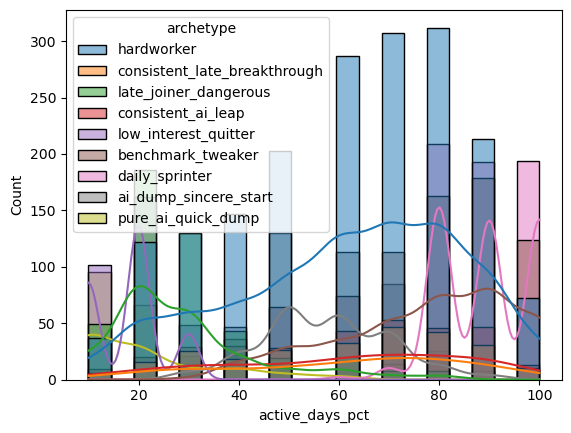

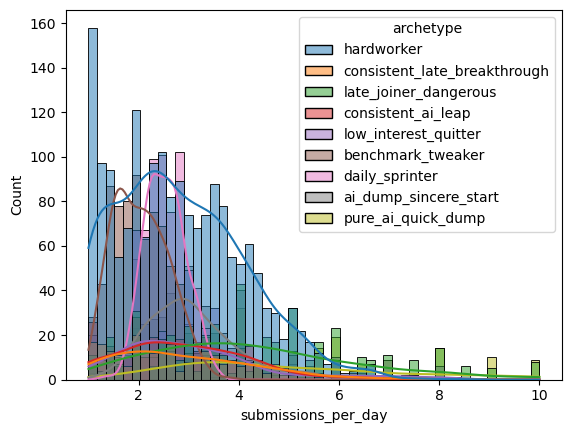

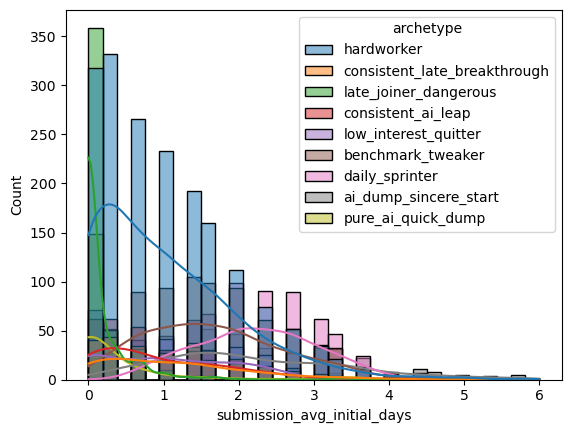

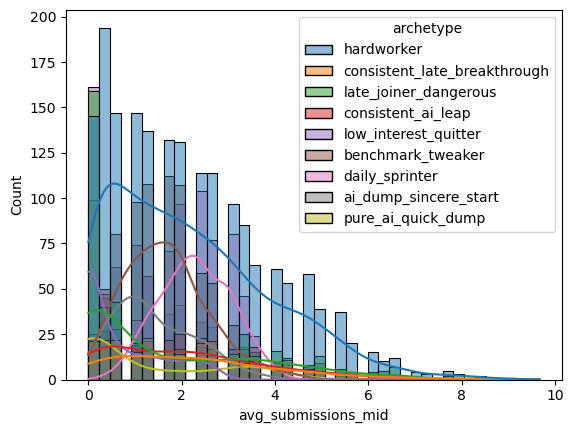

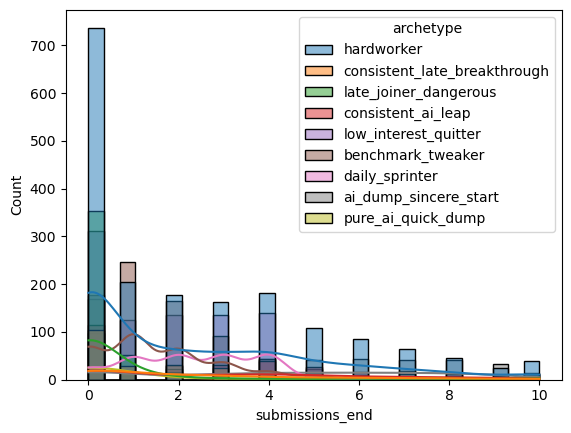

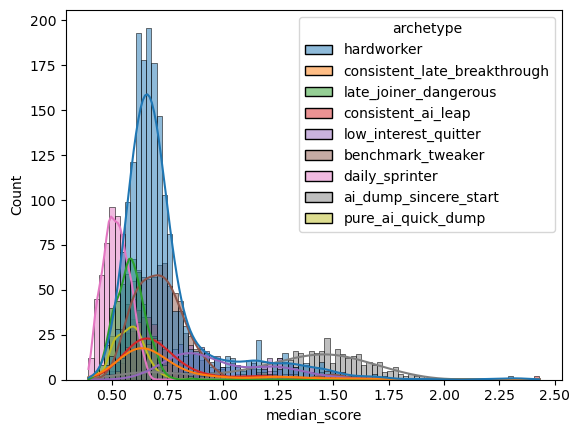

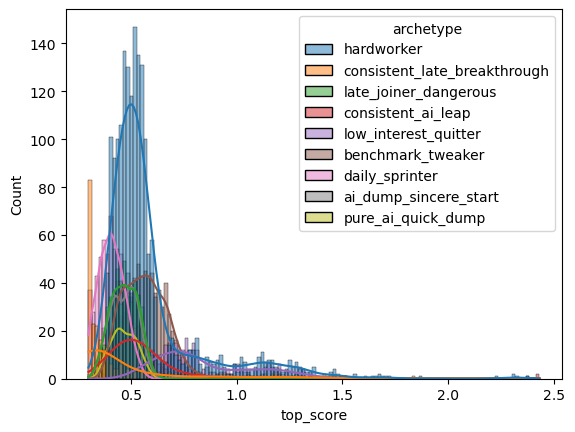

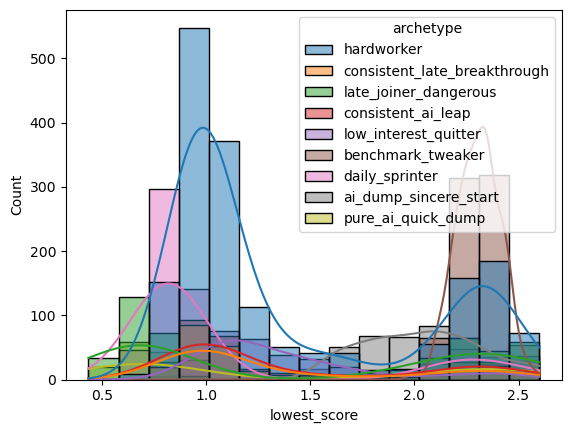

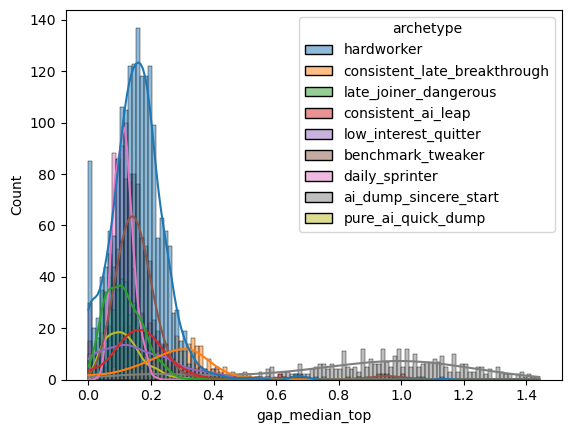

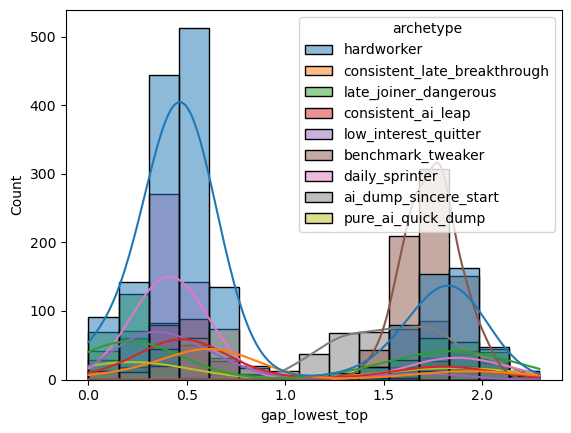

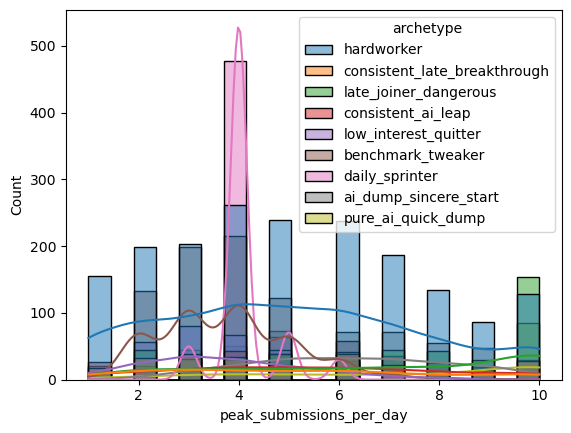

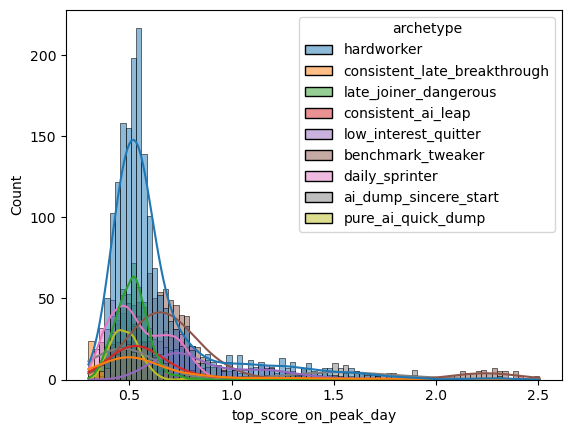

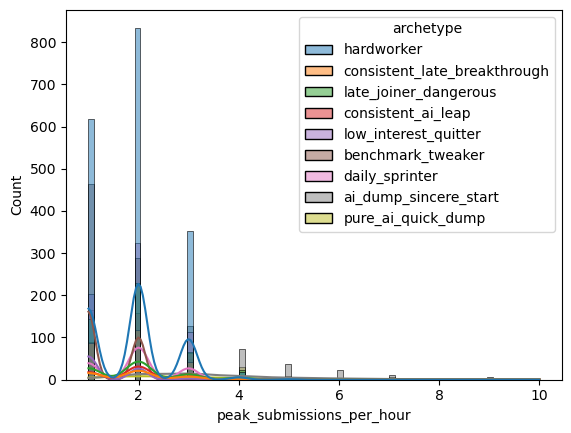

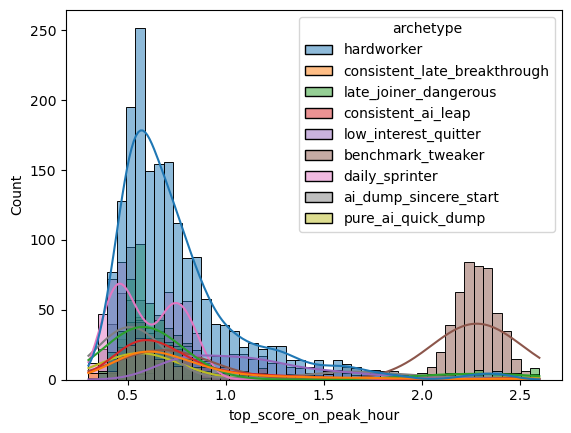

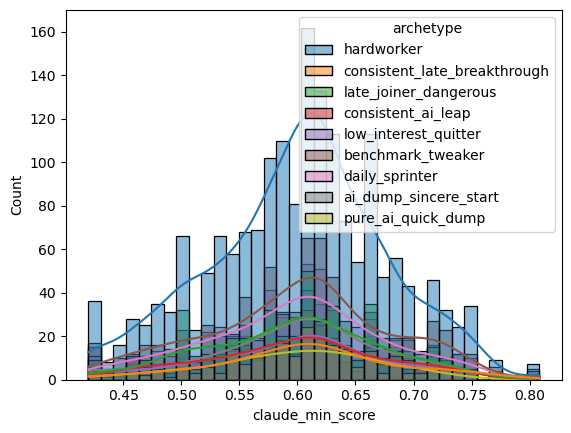

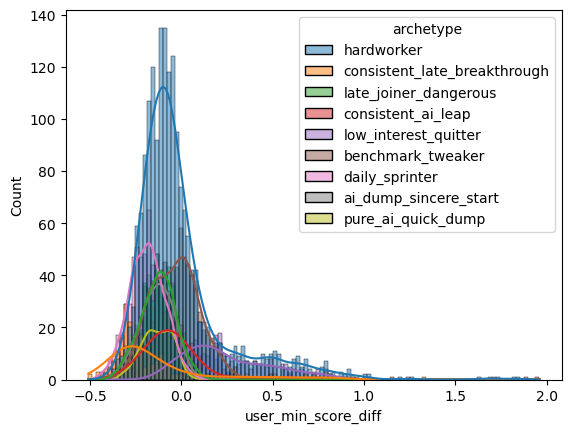

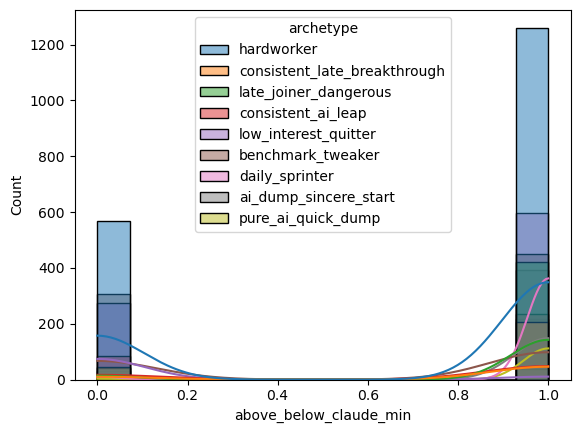

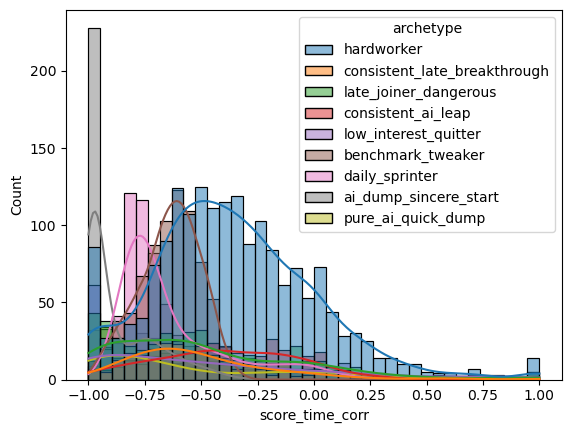

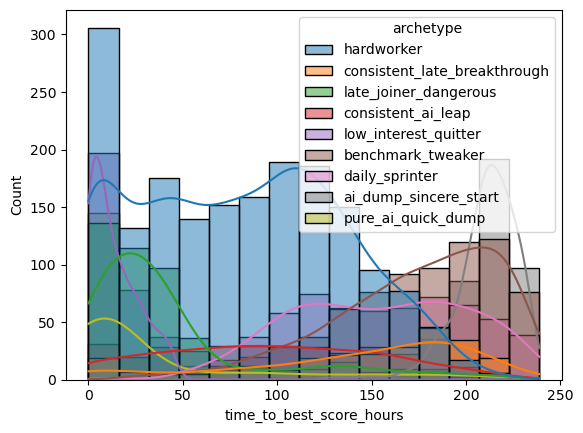

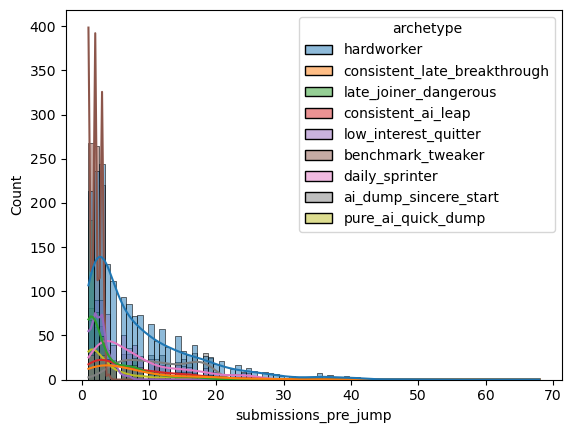

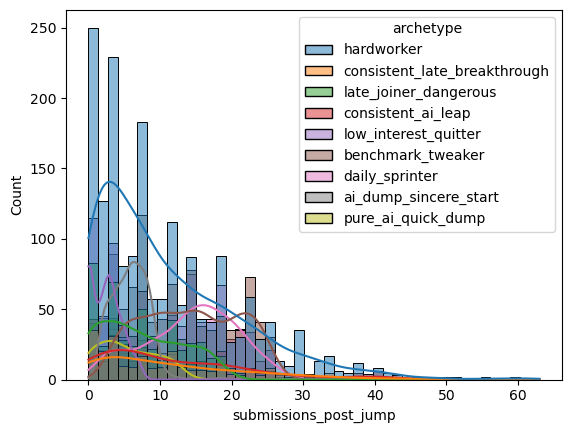

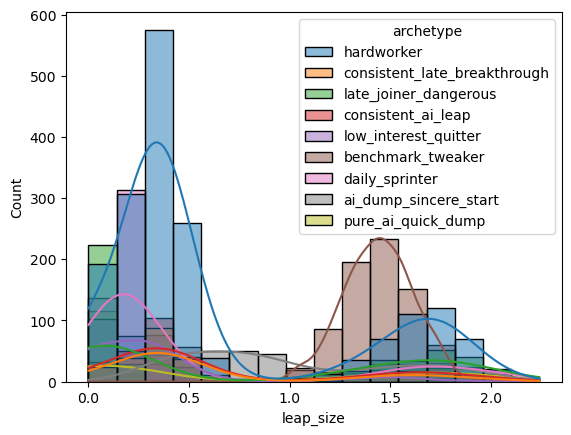

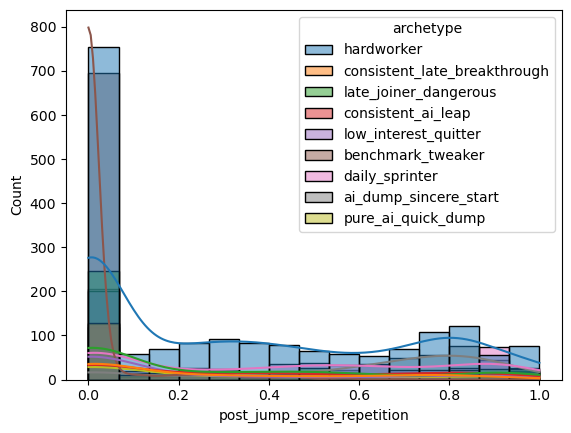

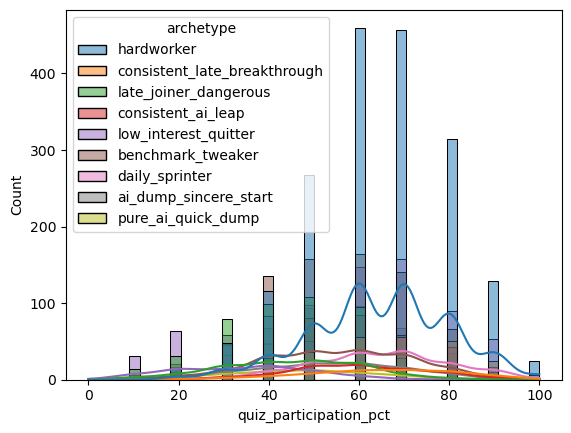

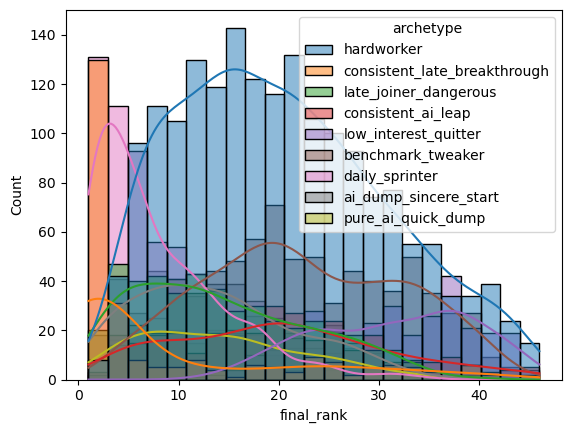

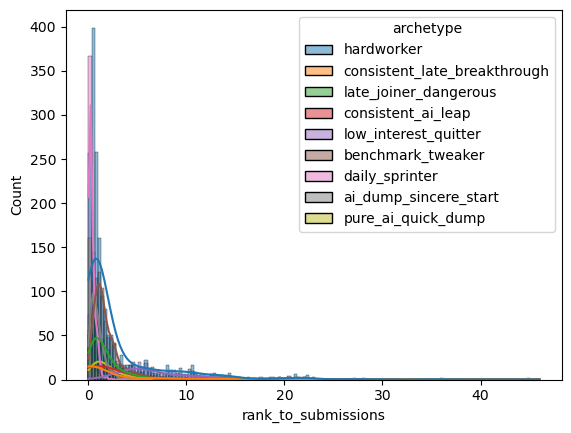

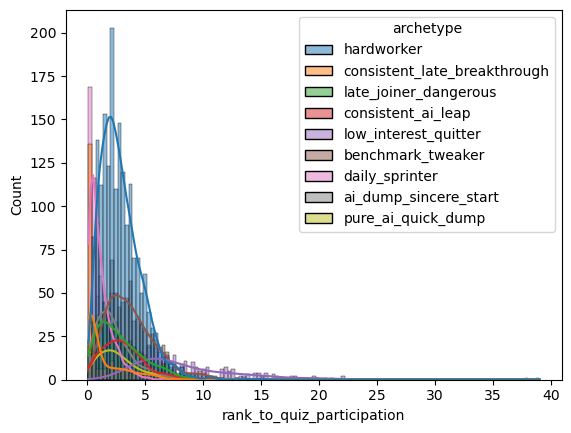

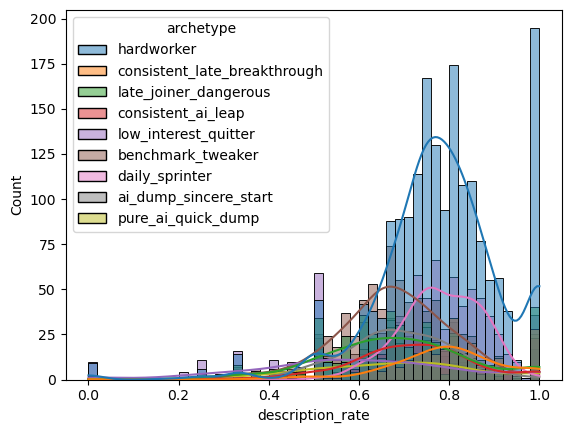

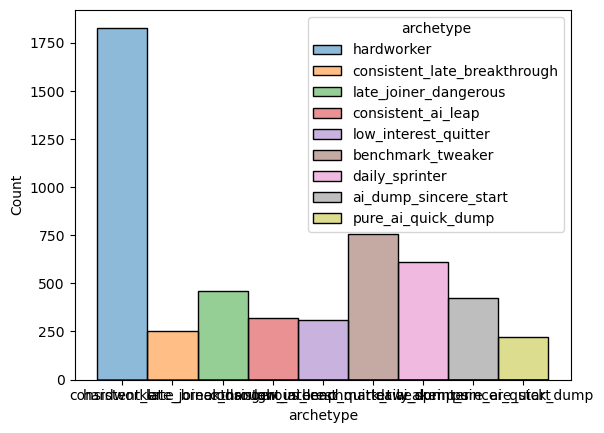

KeyError: 'quiz_participation'

In [12]:
sns.kdeplot(data = df, x= 'top_score', hue = 'archetype')
plt.show()
plt.close()
for i in df.columns:
    sns.histplot(data = df, x= i, hue = 'archetype', kde=True)
    plt.show()
    plt.close()

# display(df2['BMI'].describe())
# df['BMI'].describe()
cat_columns = ['active_days_pct', 'peak_submissions_per_hour', 'peak_submissions_per_day', 'quiz_participation','final_rank', 'archetype']
d = {i:np.sort(df[i].unique()) for i in cat_columns}
d

In [ ]:
# cheated = df['cheated'].sum()
# cat_columns = ['active_days', 'peak_submissions_per_hour', 'peak_submissions_per_day', 'quiz_participation','final_rank']
# for i in cat_columns:
#     if i == 'cheated':
#         continue
#     print(i)
#     for j in d[i]:
#         a = df[df[i] == j]
#         b = a['cheated'].sum()
        
#         print(f"       {j} :\n       Probability of cheating = {(b*100)/(a.shape[0])}       [[TD:{a.shape[0]} '+' :{b}]]\n       overall '+'ve contribution : {(b*100)/(cheated)}")

active_days
       1 :
       Probability of cheating = 53.30882352941177       [[TD:272 '+' :145]]
       overall '+'ve contribution : 8.950617283950617
       2 :
       Probability of cheating = 50.610820244328096       [[TD:573 '+' :290]]
       overall '+'ve contribution : 17.901234567901234
       3 :
       Probability of cheating = 46.42857142857143       [[TD:392 '+' :182]]
       overall '+'ve contribution : 11.234567901234568
       4 :
       Probability of cheating = 39.20265780730897       [[TD:301 '+' :118]]
       overall '+'ve contribution : 7.283950617283951
       5 :
       Probability of cheating = 48.922413793103445       [[TD:464 '+' :227]]
       overall '+'ve contribution : 14.012345679012345
       6 :
       Probability of cheating = 37.023593466424686       [[TD:551 '+' :204]]
       overall '+'ve contribution : 12.592592592592593
       7 :
       Probability of cheating = 29.124579124579125       [[TD:594 '+' :173]]
       overall '+'ve contribution : 10.6

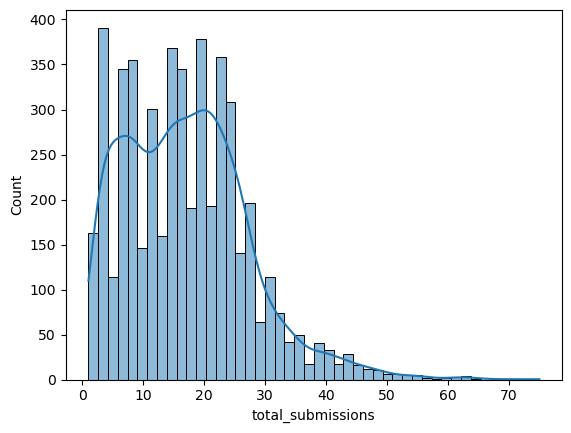

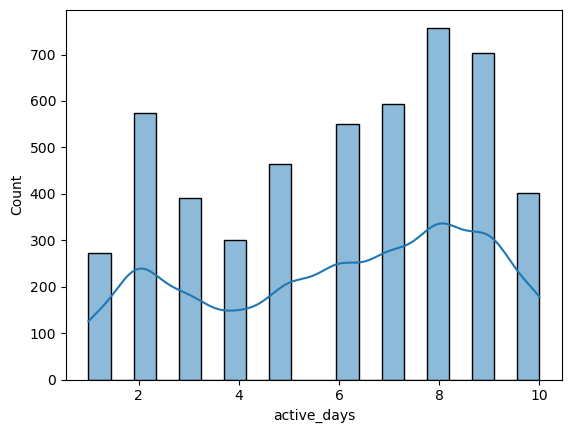

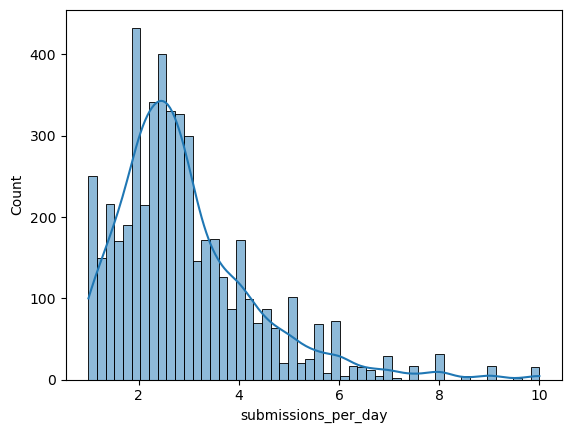

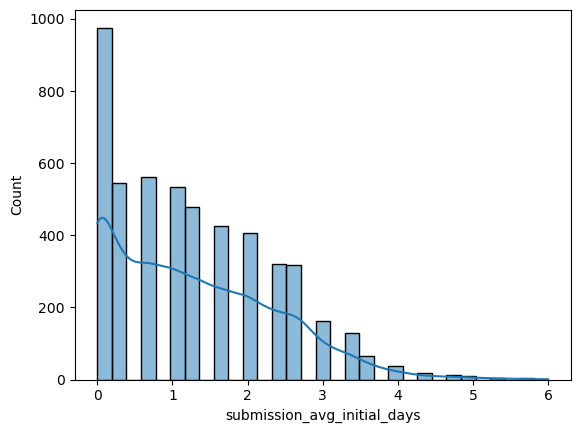

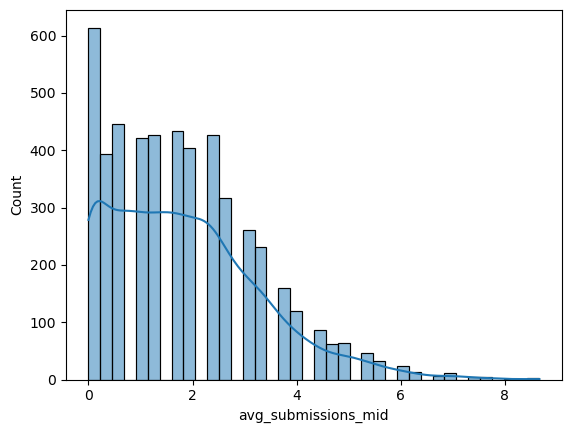

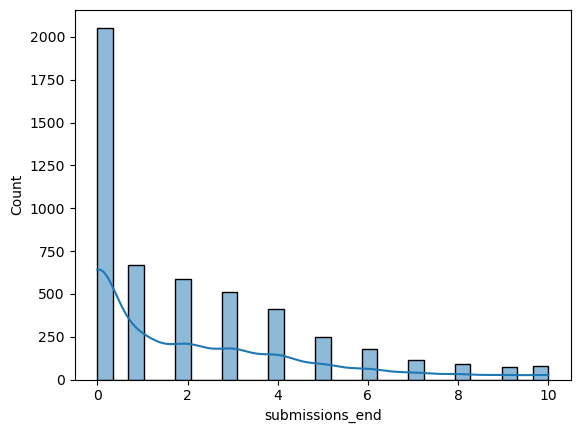

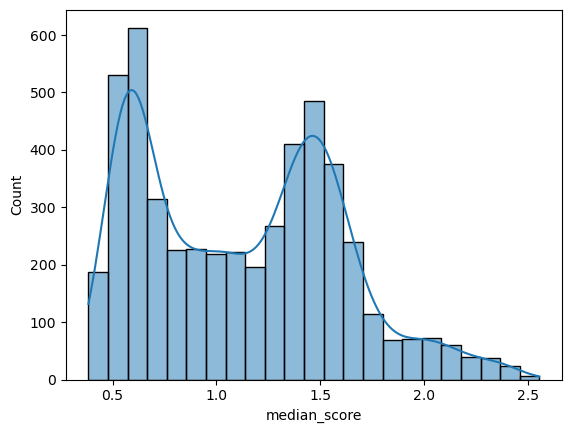

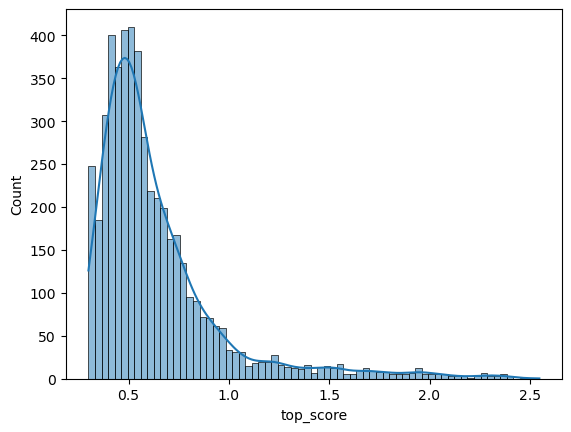

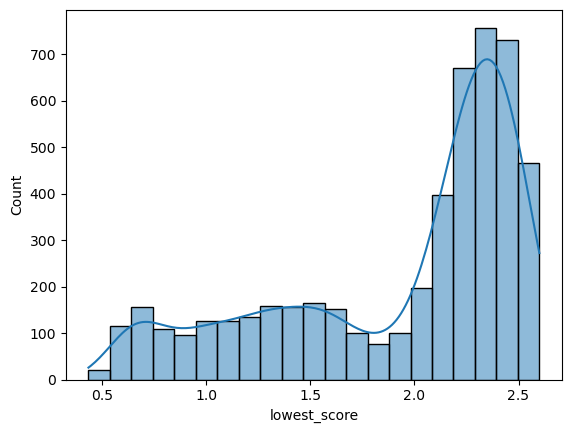

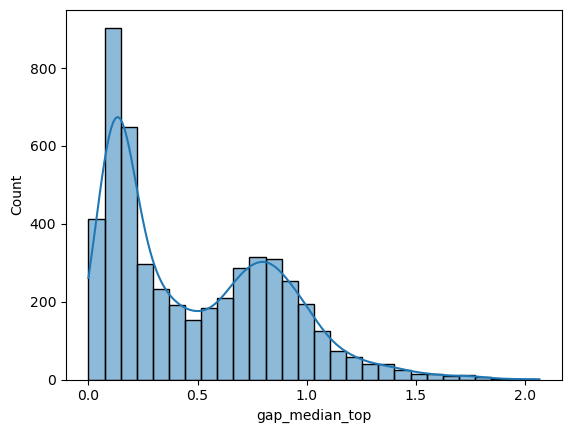

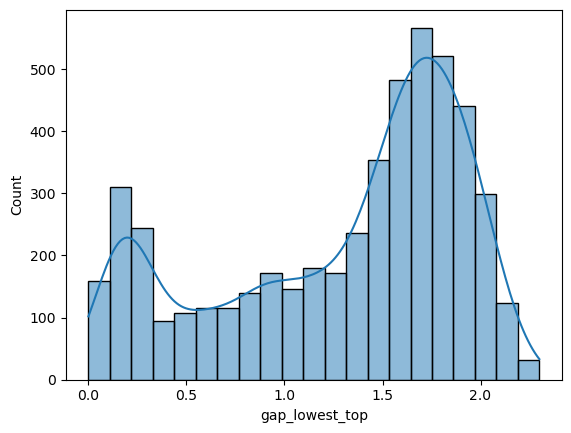

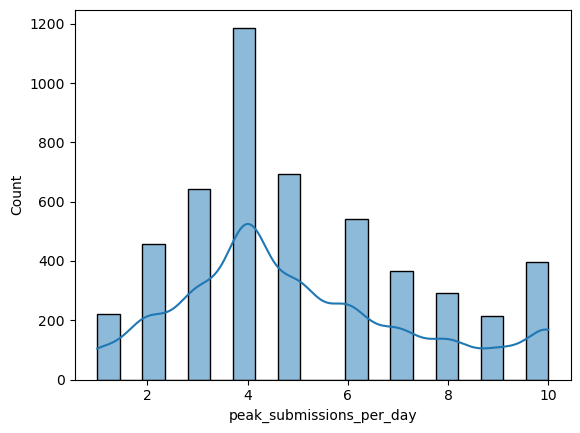

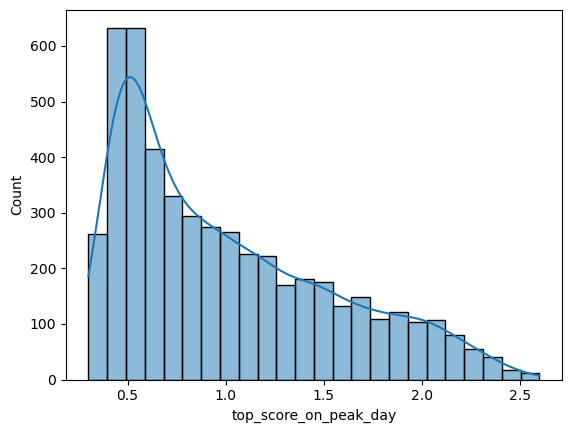

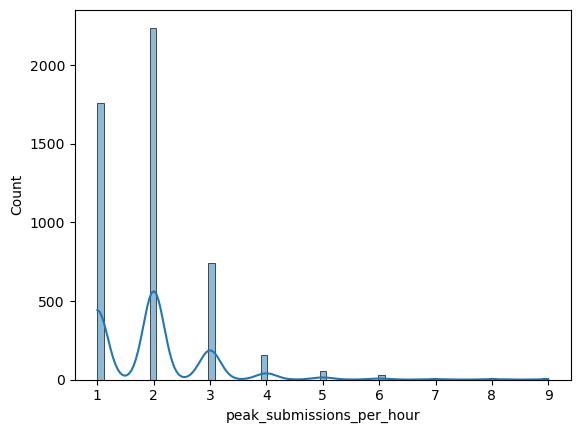

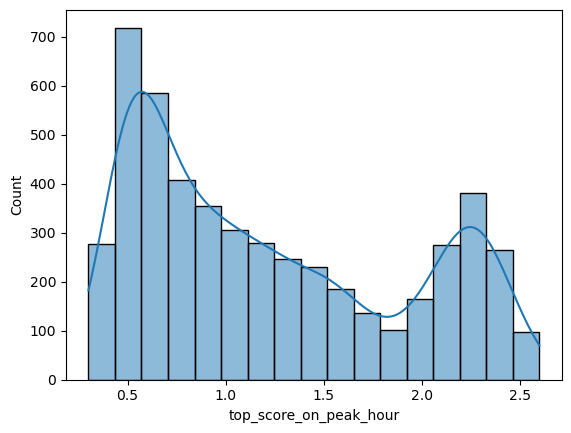

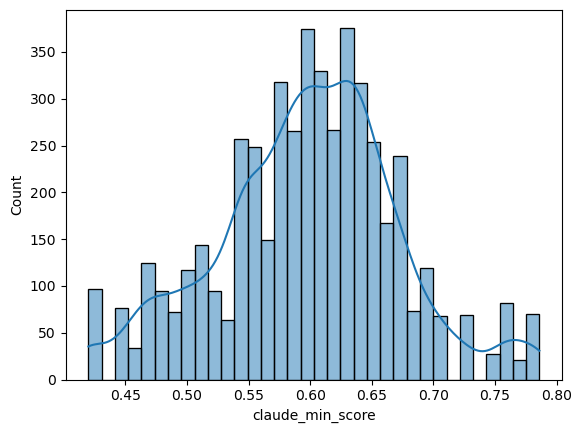

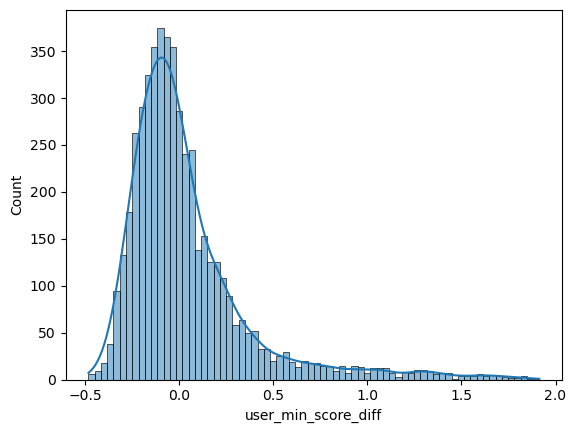

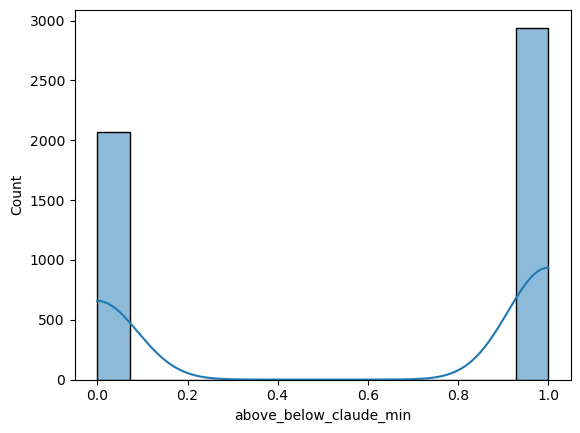

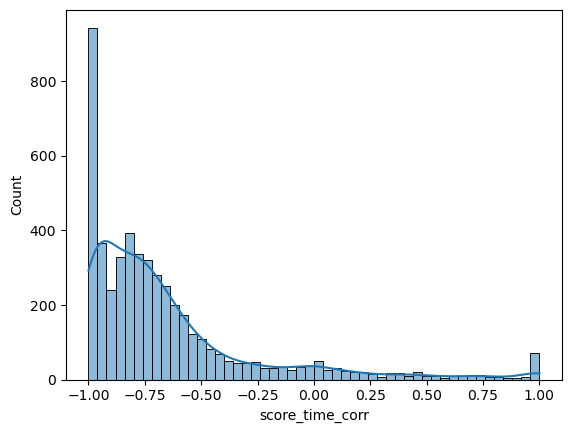

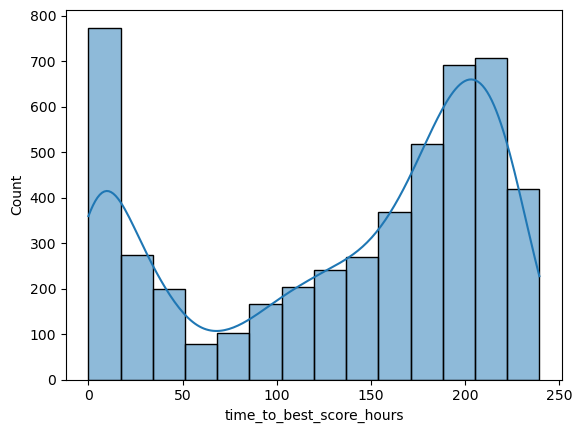

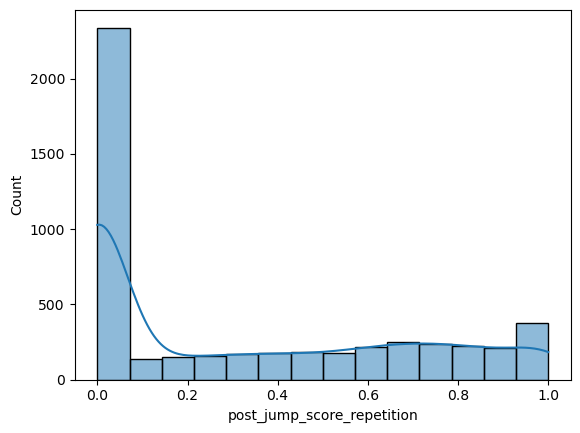

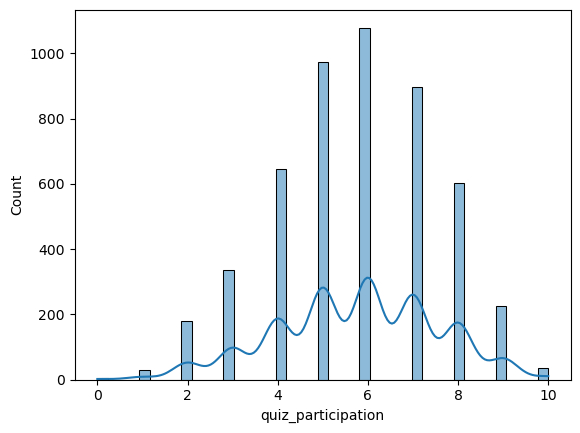

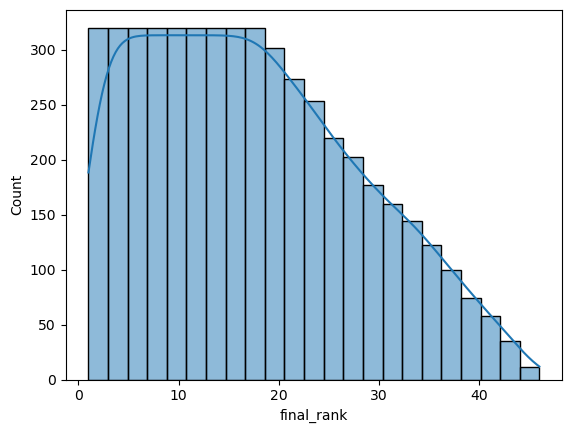

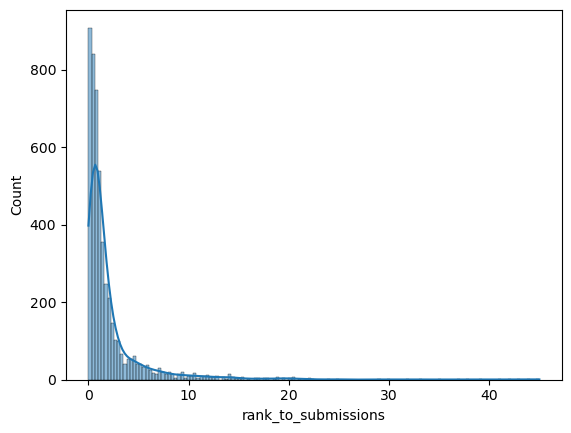

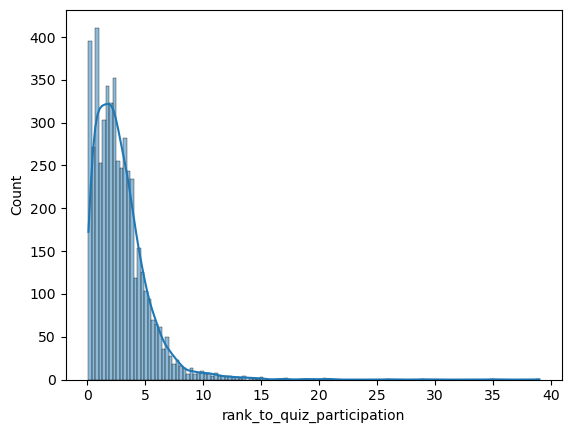

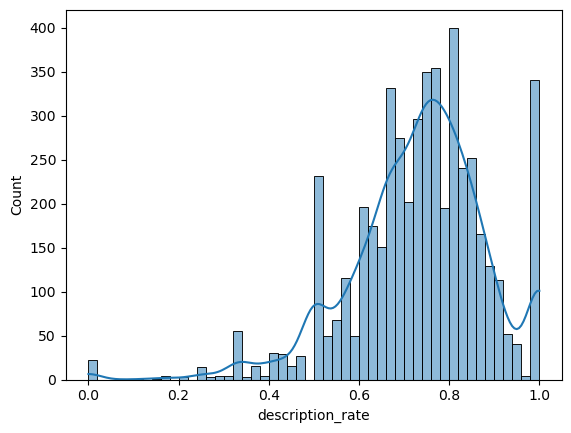

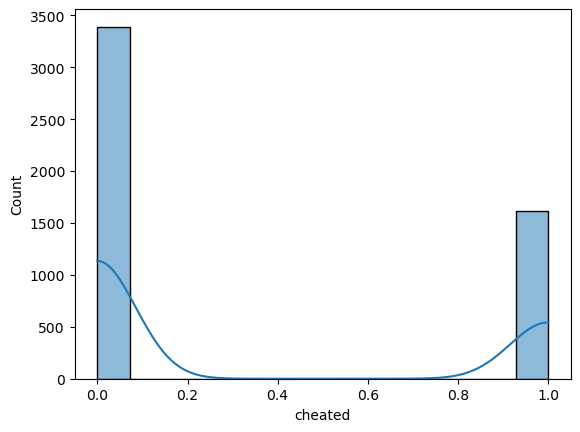

In [ ]:
for i in df.columns:
    sns.histplot(data = df, x= i, kde=True)
    plt.show()
    plt.close()